In [13]:
%matplotlib inline
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import uproot
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.optimize import curve_fit
from LHCb_ch import funcgeneral, models, analisis, mK, mPi

# Rutas de las carpetas
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / 'Data'
Path('GChanels').mkdir(exist_ok = True)

print("Configuración cargada correctamente.")
print(f"Directorio de datos; {DATA_DIR}")

Configuración cargada correctamente.
Directorio de datos; /home/karna/Documentos/LHCb/Hackaton_2024/opendata-project-1.2/Data


# Canal $B^{\pm} \to K^{+}K^{-}K^{+}$


  CANAL: B⇾KKK

[1] Cargando datos...
  B2HHH_MagnetUp.root: 39,229 eventos
  B2HHH_MagnetDown.root: 59,379 eventos
  Total tras preselección: 98,608 eventos

[2] Reconstruyendo masa invariante del B...

[3] Ajuste de la distribución de masa...
  B⁺: 50,195 candidatos en [5100.0,5500.0] MeV/c²
N_señal = 10529 ± 129
χ²/ndf  = 141.3 / 75
Media   = 5284.83 [MeV/c²]
  σ     = 17.96 [MeV/c²]
  B⁻: 48,413 candidatos en [5100.0,5500.0] MeV/c²
N_señal = 9823 ± 126
χ²/ndf  = 122.9 / 75
Media   = 5284.65 [MeV/c²]
  σ     = 18.15 [MeV/c²]


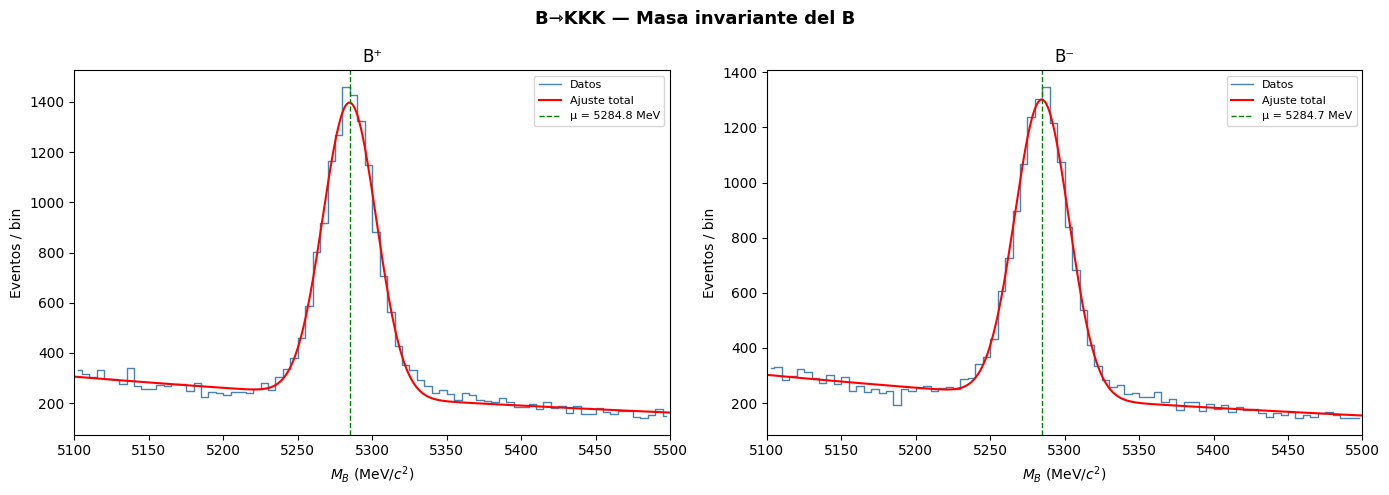


[5] Asimetría CP global (conteo simple)...

=== B⇾KKK — conteo simple ===
  N+ = 50,195   N- = 48,413
  A_CP = -0.0181 ± 0.0032
  Significancia = -5.68 σ

=== B⇾KKK — del ajuste ===
  N+ = 10,528   N- = 9,823
  A_CP = -0.0346 ± 0.0070
  Significancia = -4.94 σ

[6] Diagramas de Dalitz...


AttributeError: 'NoneType' object has no attribute 'query'

In [15]:
PRESELECTION_KKK = (
    '(H1_isMuon==0) & (H2_isMuon==0) & (H3_isMuon==0)'
    ' & (H1_ProbK > 0.5) & (H3_ProbK > 0.5) & (H3_ProbK > 0.5)'
    ' & (H1_ProbPi < 0.5) & (H3_ProbPi < 0.5) & (H3_ProbPi < 0.5)'
)
MASSES_KKK = (mK, mK, mK)

results_KKK = analisis.run_channel_analysis(
    channel_name = "B⇾KKK",
    preselection = PRESELECTION_KKK,
    masses = MASSES_KKK,
    fit_model = 'gauss_exp',
    charm_veto = True,
    use_sideband = False,
    mass_window = (5197, 5364)
)